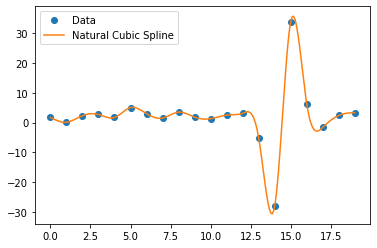

In [12]:
#Part A
import numpy as np
import matplotlib.pyplot as plt

#calculate second derivatives for natural spline
def spline_coeffs(x, y):
    n = len(x)
    h = np.diff(x)

    mat = np.zeros((n-2, n-2))
    rhs = np.zeros(n-2)

    for i in range(1, n-1):
        r = i-1

        if r > 0:
            mat[r, r-1] = h[i-1]

        mat[r, r] = 2*(h[i-1] + h[i])

        if r < n-3:
            mat[r, r+1] = h[i]

        slope1 = (y[i+1] - y[i]) / h[i]
        slope2 = (y[i] - y[i-1]) / h[i-1]
        rhs[r] = 6*(slope1 - slope2)

#natural boundary conditions
    Mvals = np.zeros(n)
    Mvals[1:n-1] = np.linalg.solve(mat, rhs)

    return Mvals

#evaluate at given points
def spline_eval(x, y, Mvals, pts):
    y_out = []

    for val in pts:
        
        #find interval
        if val <= x[0]:
            i = 0
        elif val >= x[-1]:
            i = len(x)-2
        else:
            i = np.searchsorted(x, val) - 1

        h = x[i+1] - x[i]

        a = (x[i+1] - val)
        b = (val - x[i])

        term1 = Mvals[i]*(a**3)/(6*h)
        term2 = Mvals[i+1]*(b**3)/(6*h)
        term3 = (y[i] - Mvals[i]*h*h/6)*(a/h)
        term4 = (y[i+1] - Mvals[i+1]*h*h/6)*(b/h)

        y_out.append(term1 + term2 + term3 + term4)

    return np.array(y_out)

#data
x = np.arange(20)
y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

#computes spline
Mvals = spline_coeffs(x, y)

#create curve
x_vals = np.linspace(x[0], x[-1], 200)
y_vals = spline_eval(x, y, Mvals, x_vals)

#plot
plt.plot(x, y, 'o', label='data')
plt.plot(x_vals, y_vals, label='natural cubic spline')
plt.legend()
plt.show()

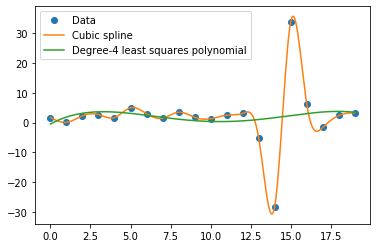

Coefficients:
[-1.17213791e-03  4.97826435e-02 -6.67339138e-01  2.95370441e+00
 -4.65372671e-01]


In [14]:
#Part B
import numpy as np
import matplotlib.pyplot as plt

def spline_coeffs(x, y):
    n = len(x)
    h = np.diff(x)

    mat = np.zeros((n-2, n-2))
    rhs = np.zeros(n-2)

    for i in range(1, n-1):
        r = i-1

        if r > 0:
            mat[r, r-1] = h[i-1]

        mat[r, r] = 2*(h[i-1] + h[i])

        if r < n-3:
            mat[r, r+1] = h[i]

        slope1 = (y[i+1] - y[i]) / h[i]
        slope2 = (y[i] - y[i-1]) / h[i-1]
        rhs[r] = 6*(slope1 - slope2)

    Mvals = np.zeros(n)
    Mvals[1:n-1] = np.linalg.solve(mat, rhs)
    return Mvals

def spline_eval(x, y, Mvals, pts):
    y_out = []

    for val in pts:
        if val <= x[0]:
            i = 0
        elif val >= x[-1]:
            i = len(x)-2
        else:
            i = np.searchsorted(x, val) - 1

        h = x[i+1] - x[i]
        a = x[i+1] - val
        b = val - x[i]

        term1 = Mvals[i]*(a**3)/(6*h)
        term2 = Mvals[i+1]*(b**3)/(6*h)
        term3 = (y[i] - Mvals[i]*h*h/6)*(a/h)
        term4 = (y[i+1] - Mvals[i+1]*h*h/6)*(b/h)

        y_out.append(term1 + term2 + term3 + term4)

    return np.array(y_out)

# data
x = np.arange(20, dtype=float)
y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3], dtype=float)

# cubic spline
Mvals = spline_coeffs(x, y)

# degree-4 least squares polynomial using Vandermonde matrix
A = np.column_stack((x**4, x**3, x**2, x, np.ones(len(x))))
coef = np.linalg.solve(A.T @ A, A.T @ y)

# evaluate both on a fine grid
x_plot = np.linspace(x[0], x[-1], 300)
y_spline = spline_eval(x, y, Mvals, x_plot)
y_poly4 = coef[0]*x_plot**4 + coef[1]*x_plot**3 + coef[2]*x_plot**2 + coef[3]*x_plot + coef[4]

# plot
plt.plot(x, y, 'o', label='Data')
plt.plot(x_plot, y_spline, label='Cubic spline')
plt.plot(x_plot, y_poly4, label='Degree-4 least squares polynomial')
plt.legend()
plt.show()

print("Coefficients:")
print(coef)

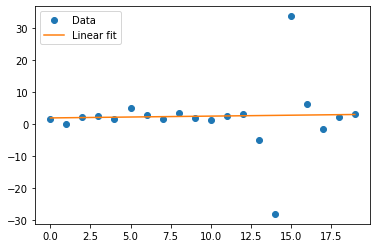

slope: 0.056617647058823675
intercept: 1.9592647058823527


In [17]:
#Least Squares Method
import numpy as np
import matplotlib.pyplot as plt

# original data
X = np.arange(20)
Y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

# remove Covid quarters
mask = np.ones(len(X), dtype=bool)
mask[13:18] = False

X_fit = X[mask]
Y_fit = Y[mask]

# Same method from class
A = np.vstack([X_fit, np.ones(len(X_fit))]).T

m, c = np.linalg.lstsq(A, Y_fit, rcond=None)[0]

y_line = m * X + c

plt.plot(X, Y, 'o', label='Data')          # original data
plt.plot(X, y_line, label='Linear fit')    # fitted line
plt.legend()
plt.show()
print("slope:", m)
print("intercept:", c)

In [ ]:
#AI was used to assist with structuring code, debugging syntax issues, and clarifying concepts related to cubic spline interpolation and least squares methods. The AI did not generate the full solution, but helped refine logic and organization.

#AI Tool
#ChatGPT

#Prompt Used
#“Help me implement a natural cubic spline using a tridiagonal system without using built-in libraries, and explain each step clearly.”